|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 5:</h2>|<h1>Making It Fast<h1>|
|<h2>Section:</h2>|<h1>Sampling<h1>|
|<h2>Lecture:</h2>|<h1><b>Temperature, top-k, top-p and penalties on eight words<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# Four knobs, on numbers you can read

The model hands you a vector of logits. Everything between that and a token
is policy, and every request gets its own.

Start with eight words instead of a hundred and fifty thousand.

In [2]:
torch.manual_seed(0)

words  = ['the','a','cat','dog','ran','slept','quickly','purple']
logits = torch.tensor([3.2, 2.8, 1.9, 1.7, 0.9, 0.6, -0.4, -2.1])

probs = F.softmax(logits, dim=-1)
for w, l, p in zip(words, logits, probs):
  print(f'{w:>9} {l:6.2f} -> {p:6.3f}  {"#"*int(60*p)}')

      the   3.20 ->  0.421  #########################
        a   2.80 ->  0.282  ################
      cat   1.90 ->  0.115  ######
      dog   1.70 ->  0.094  #####
      ran   0.90 ->  0.042  ##
    slept   0.60 ->  0.031  #
  quickly  -0.40 ->  0.012  
   purple  -2.10 ->  0.002  


### Temperature

Divide the logits before the softmax. Below 1 the distribution sharpens
toward the argmax; above 1 it flattens toward uniform.

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

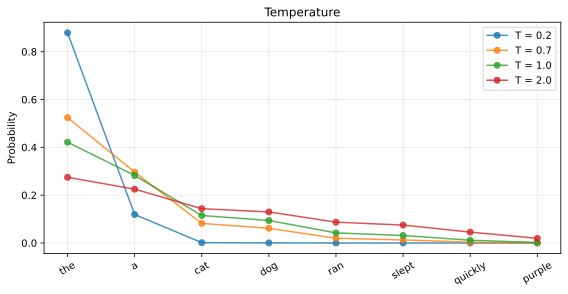

T= 0.2: top token 0.879, entropy 0.379 nats
T= 0.7: top token 0.525, entropy 1.228 nats
T= 1.0: top token 0.421, entropy 1.499 nats
T= 2.0: top token 0.275, entropy 1.858 nats


In [3]:
temps = [0.2, 0.7, 1.0, 2.0]

plt.figure(figsize=(8,4.2))
for T in temps:
  plt.plot(F.softmax(logits/T, dim=-1), 'o-', alpha=.8, label=f'T = {T}')
plt.xticks(range(len(words)), words, rotation=30)
plt.ylabel('Probability'); plt.title('Temperature')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

for T in temps:
  p = F.softmax(logits/T, dim=-1)
  ent = -(p*p.log()).sum()
  print(f'T={T:4}: top token {p.max():.3f}, entropy {ent:.3f} nats')

Temperature 0 is not a temperature. It is a separate code path, because the
formula divides by it. Greedy decoding is the limit, not a setting.

### Top-k: keep the k best, drop the rest

In [4]:
def top_k(logits, k):
  out = logits.clone()
  if k < len(logits):
    threshold = torch.topk(logits, k).values[-1]
    out[out < threshold] = float('-inf')
  return out

for k in (1, 3, 5, 8):
  p = F.softmax(top_k(logits, k), dim=-1)
  kept = (p > 0).sum().item()
  print(f'k={k}: {kept} tokens survive, top {p.max():.3f}, '
        f'{" ".join(w for w,x in zip(words,p) if x>0)}')

k=1: 1 tokens survive, top 1.000, the
k=3: 3 tokens survive, top 0.515, the a cat
k=5: 5 tokens survive, top 0.441, the a cat dog ran
k=8: 8 tokens survive, top 0.421, the a cat dog ran slept quickly purple


### Top-p: keep the smallest set that covers p of the mass

Top-k always keeps k tokens, whether the model was confident or not. Top-p
adapts: one token when the model is sure, many when it is not.

In [5]:
def top_p(logits, p):
  srt, idx = torch.sort(logits, descending=True)
  cum = F.softmax(srt, dim=-1).cumsum(dim=-1)
  # keep everything up to and INCLUDING the one that crosses p
  drop = cum - F.softmax(srt, dim=-1) >= p
  srt[drop] = float('-inf')
  out = torch.empty_like(logits)
  out[idx] = srt
  return out

for pv in (0.5, 0.8, 0.95, 1.0):
  q = F.softmax(top_p(logits, pv), dim=-1)
  print(f'p={pv:4}: {(q>0).sum().item()} tokens, '
        f'{" ".join(w for w,x in zip(words,q) if x>0)}')

p= 0.5: 2 tokens, the a
p= 0.8: 3 tokens, the a cat
p=0.95: 5 tokens, the a cat dog ran
p= 1.0: 8 tokens, the a cat dog ran slept quickly purple


In [6]:
# the adaptive part: a confident distribution and an unsure one
confident = torch.tensor([6.0, 1.0, 0.5, 0.2, 0.0, -0.5, -1.0, -2.0])
unsure    = torch.tensor([1.2, 1.1, 1.05, 1.0, 0.95, 0.9, 0.85, 0.8])

for name, lg in (('confident', confident), ('unsure', unsure)):
  for pv in (0.9, 0.95):
    n = (F.softmax(top_p(lg, pv), dim=-1) > 0).sum().item()
    print(f'{name:>10} at p={pv}: keeps {n} tokens')
  n = (F.softmax(top_k(lg, 3), dim=-1) > 0).sum().item()
  print(f'{name:>10} at k=3:   keeps {n} tokens   <- always 3, regardless')

 confident at p=0.9: keeps 1 tokens
 confident at p=0.95: keeps 1 tokens
 confident at k=3:   keeps 3 tokens   <- always 3, regardless
    unsure at p=0.9: keeps 8 tokens
    unsure at p=0.95: keeps 8 tokens
    unsure at k=3:   keeps 3 tokens   <- always 3, regardless


### Repetition penalty, and the sign trap

Divide the logits of tokens already seen. The trap: for a **negative** logit,
dividing by a number greater than one makes it larger, which is the opposite
of a penalty. The usual fix is to multiply when the logit is negative.

In [7]:
seen   = torch.tensor([0, 2])          # 'the' and 'cat' already appeared
penalty = 1.5

naive = logits.clone()
naive[seen] = naive[seen] / penalty

correct = logits.clone()
sel = correct[seen]
correct[seen] = torch.where(sel > 0, sel/penalty, sel*penalty)

negative = torch.tensor([-1.0, 2.0])
print('a negative logit, divided by 1.5:  ', (negative[0]/penalty).item(), ' <- went UP')
print('a negative logit, multiplied by 1.5:', (negative[0]*penalty).item(), ' <- went down')
print()
for w, a, b in zip(words, naive, correct):
  if not torch.isclose(a, b):
    print(f'{w:>9}: naive {a:6.2f}, correct {b:6.2f}')
print('\n(no difference here because both seen logits were positive.)')
print('It shows up on a token the model already disliked, which is exactly')
print('the case where a penalty should not be a reward.')

a negative logit, divided by 1.5:   -0.6666666865348816  <- went UP
a negative logit, multiplied by 1.5: -1.5  <- went down


(no difference here because both seen logits were positive.)
It shows up on a token the model already disliked, which is exactly
the case where a penalty should not be a reward.


### The order matters

Penalty, then temperature, then top-k, then top-p, then sample. Swap
temperature and top-p and you get a different distribution, because top-p
measures mass and temperature moves it.

    ./vc guide 13